# 05 — Comparative Evaluation
**Contributors:** Paula Evangelista  
**Group 2 | Inside Airbnb Madrid**

Consolidates all results from Notebooks 01–04:

1. **Standardised Comparison Table** — required by assignment rubric
2. **Grouped Bar Chart** — all 6 metrics side by side
3. **Radar Chart** — beyond-accuracy dimensions  
4. **Cold-Start Curve** — Precision@10 vs listing review count
5. **Simulated A/B Test** — statistical significance of CARS vs Content-Based
6. **Bias Evaluation** — Gini concentration coefficient

In [33]:
import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content'
    print('✓ Google Drive mounted')
except ImportError:
    # Running locally — data folder is next to the notebooks
    DATA_DIR = 'data'
    print('✓ Running locally — using data/ folder')

LISTINGS_PATH = os.path.join(DATA_DIR, 'listings.csv.gz')
REVIEWS_PATH  = os.path.join(DATA_DIR, 'reviews.csv')
print(f'Listings : {LISTINGS_PATH}')
print(f'Reviews  : {REVIEWS_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted
Listings : /content/listings.csv.gz
Reviews  : /content/reviews.csv


In [34]:
import os
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)
print('✓ Libraries loaded')
print("✓ 'figures/' directory ready")

✓ Libraries loaded
✓ 'figures/' directory ready


## 1. Run All Four Models & Collect Metrics

> This notebook re-runs compact versions of all four recommenders on the same data so the comparison table reflects actual computed numbers, not hardcoded values

In [35]:
# ── Load & clean data (same pipeline as NB01–04) ─────────────────────────────
listings = pd.read_csv(LISTINGS_PATH, low_memory=False)
reviews  = pd.read_csv(REVIEWS_PATH,  low_memory=False)
reviews['date'] = pd.to_datetime(reviews['date'])

listings['price_clean'] = (
    listings['price'].astype(str).str.replace(r'[\$,]', '', regex=True)
    .replace('', np.nan).astype(float)
)
listings = listings[listings['price_clean'].isna() | (listings['price_clean'] <= 2000)].copy()
listings['price_clean'] = listings['price_clean'].fillna(listings['price_clean'].median())

listings = pd.read_csv(LISTINGS_PATH, low_memory=False)
reviews  = pd.read_csv(REVIEWS_PATH,  low_memory=False)
reviews['date'] = pd.to_datetime(reviews['date'])

listings['price_clean'] = (
    listings['price'].astype(str).str.replace(r'[\$,]', '', regex=True)
    .replace('', np.nan).astype(float)
)
listings = listings[listings['price_clean'].isna() | (listings['price_clean'] <= 2000)].copy()
listings['price_clean'] = listings['price_clean'].fillna(listings['price_clean'].median())

listings['review_scores_rating'] = pd.to_numeric(listings['review_scores_rating'], errors='coerce')
listings['review_scores_rating'] = (
    listings.groupby('neighbourhood_cleansed')['review_scores_rating']
    .transform(lambda x: x.fillna(x.mean()))
    .fillna(listings['review_scores_rating'].mean())
)
listings['number_of_reviews'] = pd.to_numeric(listings['number_of_reviews'], errors='coerce').fillna(0)
listings['accommodates']      = pd.to_numeric(listings['accommodates'], errors='coerce').fillna(2)
listings['is_superhost']      = (listings['host_is_superhost'] == 't').astype(int)
listings['is_instant_book']   = (listings['instant_bookable']  == 't').astype(int)

amenity_map = {
    'wifi':'wifi|wi-fi','kitchen':'kitchen','ac':'air conditioning',
    'heating':'heating','washer':r'washer|washing machine','tv':r'\btv\b|television',
    'parking':'parking|garage','elevator':'elevator|lift',
    'gym':r'\bgym\b|fitness center','pets':'pets allowed'
}
ams = listings['amenities'].fillna('').str.lower()
for name, pat in amenity_map.items():
    listings[f'am_{name}'] = ams.str.contains(pat, regex=True).astype(int)

C, m = listings['review_scores_rating'].mean(), 50
listings['bayesian_avg'] = (
    (listings['number_of_reviews']/(listings['number_of_reviews']+m)) * listings['review_scores_rating']
    + (m/(listings['number_of_reviews']+m)) * C
)

SPLIT_DATE = pd.Timestamp('2024-07-01')
train_rev = reviews[reviews['date'] <  SPLIT_DATE].copy()
test_rev  = reviews[reviews['date'] >= SPLIT_DATE].copy()

print(f'Listings: {len(listings):,} | Train: {len(train_rev):,} | Test: {len(test_rev):,}')
print('✓ Data loaded and cleaned')


Listings: 24,958 | Train: 862,549 | Test: 413,443
✓ Data loaded and cleaned


In [36]:
# ── Shared evaluation helpers ────────────────────────────────────────────────
from collections import Counter
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

TOP_K = 10  # Cut-off for Precision@K, Recall@K, NDCG (table columns use generic @K)

def precision_at_k(rec, rel, k=TOP_K):
    return len(set(rec[:k]) & rel) / k
def recall_at_k(rec, rel, k=TOP_K):
    return len(set(rec[:k]) & rel) / len(rel) if rel else 0
def ndcg_at_k(rec, rel, k=TOP_K):
    dcg  = sum(1/np.log2(i+2) for i, item in enumerate(rec[:k]) if item in rel)
    idcg = sum(1/np.log2(i+2) for i in range(min(k, len(rel))))
    return dcg / idcg if idcg > 0 else 0

def diversity_from_listing_table(rec_ids, L):
    """1 − mean pairwise cosine similarity on a small numeric listing profile (in-notebook proxy)."""
    if len(rec_ids) < 2:
        return np.nan
    rows = L.set_index('id')[['price_clean', 'accommodates', 'review_scores_rating']].astype(float)
    rows = rows.reindex(rec_ids).dropna(how='any')
    if rows.shape[0] < 2:
        return np.nan
    v = normalize(rows.values, norm='l2')
    sims = cos_sim(v)
    iu = np.triu_indices(rows.shape[0], k=1)
    return float(1.0 - sims[iu].mean())

def serendipity_hits(rec, rel, pop_pct_by_id, k=TOP_K):
    """Proxy: for items in rec∩rel, average (1 − popularity percentile). Requires overlap."""
    hits = list(set(rec[:k]) & rel)
    if not hits:
        return np.nan
    scores = []
    for h in hits:
        scores.append(1.0 - float(pop_pct_by_id.get(h, 0.5)))
    return float(np.mean(scores))

test_lids = set(test_rev['listing_id'].unique())
id_to_nrev = listings.set_index('id')['number_of_reviews']
pop_pct_by_id = listings.set_index('id')['number_of_reviews'].rank(pct=True).to_dict()
np.random.seed(42)
print('✓ Evaluation helpers ready')


✓ Evaluation helpers ready


### Model 1 — Non-Personalized (Bayesian Average)

In [37]:
# ── Non-Personalized evaluation ──────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error

listing_stats_np = listings[['id','review_scores_rating','number_of_reviews',
                              'neighbourhood_cleansed','price_clean','bayesian_avg']].copy()

# RMSE / MAE
test_eval = (
    test_rev
    .merge(listing_stats_np[['id','bayesian_avg']].rename(columns={'id':'listing_id'}),
           on='listing_id', how='left')
    .merge(listings[['id','review_scores_rating']].rename(columns={'id':'listing_id'}),
           on='listing_id', how='left', suffixes=('','_true'))
    .dropna(subset=['bayesian_avg','review_scores_rating'])
)
rmse_np = np.sqrt(mean_squared_error(test_eval['review_scores_rating'], test_eval['bayesian_avg']))
mae_np  = mean_absolute_error(test_eval['review_scores_rating'], test_eval['bayesian_avg'])

# Ranking metrics (same neighbourhood + test-set overlap proxy as CF/CB for comparability)
sorted_recs = listing_stats_np.sort_values('bayesian_avg', ascending=False)['id'].tolist()
sample_lids = np.random.choice(list(test_lids), min(1000, len(test_lids)), replace=False)
p1, r1, n1, rp1 = [], [], [], set()
div1, ser1 = [], []
cnt_np = Counter()
np_nrev, np_p = [], []  # cold-start binning (per evaluated query)
for lid in sample_lids:
    recs = [r for r in sorted_recs if r != lid][:TOP_K]
    hood = listings.loc[listings['id'] == lid, 'neighbourhood_cleansed'].values
    if not len(hood):
        continue
    rel = set(listings[(listings['neighbourhood_cleansed'] == hood[0]) &
                       (listings['id'].isin(test_lids))]['id']) - {lid}
    cnt_np.update(recs)
    rp1.update(recs)
    dlist = diversity_from_listing_table(recs, listings)
    if not np.isnan(dlist):
        div1.append(dlist)
    if rel:
        p1.append(precision_at_k(recs, rel))
        r1.append(recall_at_k(recs, rel))
        n1.append(ndcg_at_k(recs, rel))
        s1 = serendipity_hits(recs, rel, pop_pct_by_id)
        if np.isfinite(s1):
            ser1.append(s1)
        np_nrev.append(float(id_to_nrev.get(lid, np.nan)))
        np_p.append(p1[-1])
cov1 = len(rp1) / len(listings)

print(f'Non-Personalized:  P@{TOP_K}={np.mean(p1) if p1 else 0:.4f}  R@{TOP_K}={np.mean(r1) if r1 else 0:.4f}  '
      f'NDCG={np.mean(n1) if n1 else 0:.4f}  Cov={cov1:.4f}  Div={np.mean(div1) if div1 else 0:.4f}  '
      f'RMSE={rmse_np:.4f}')


Non-Personalized:  P@10=0.0574  R@10=0.0006  NDCG=0.0607  Cov=0.0004  Div=0.0022  RMSE=0.1459


### Model 2 — Collaborative Filtering (SVD)

In [38]:
# ── CF evaluation ────────────────────────────────────────────────────────────
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

train_rev['month'] = train_rev['date'].dt.to_period('M')
recent = train_rev[train_rev['month'] >= pd.Period('2019-01','M')]
monthly_mat = recent.groupby(['listing_id','month']).size().unstack(fill_value=0)
active_mat  = monthly_mat[monthly_mat.sum(axis=1) >= 10]

norm_mat = normalize(active_mat.values.astype(float), norm='l2')
K = min(50, min(norm_mat.shape)-1)
U, sigma, Vt = svds(csr_matrix(norm_mat.astype(np.float32)), k=K)
order = np.argsort(sigma)[::-1]
U, sigma, Vt = U[:,order], sigma[order], Vt[order,:]
embeddings = U * sigma
item_sim = cos_sim(embeddings)
item_sim_df = pd.DataFrame(item_sim, index=active_mat.index, columns=active_mat.index)

eval_ids = [lid for lid in active_mat.index if lid in test_lids]
eval_samp = np.random.choice(eval_ids, min(500, len(eval_ids)), replace=False)
p2, r2, n2, rp2, div2, ser2 = [], [], [], set(), [], []
cnt_cf = Counter()
cf_nrev, cf_p = [], []
for lid in eval_samp:
    if lid not in item_sim_df.index: continue
    recs = item_sim_df.loc[lid].drop(lid).sort_values(ascending=False).head(TOP_K).index.tolist()
    hood = listings[listings['id']==lid]['neighbourhood_cleansed'].values
    if not len(hood): continue
    rel = set(listings[(listings['neighbourhood_cleansed']==hood[0]) &
                       (listings['id'].isin(test_lids))]['id']) - {lid}
    cnt_cf.update(recs)
    if rel:
        p2.append(precision_at_k(recs, rel))
        r2.append(recall_at_k(recs, rel))
        n2.append(ndcg_at_k(recs, rel))
        s2 = serendipity_hits(recs, rel, pop_pct_by_id)
        if np.isfinite(s2):
            ser2.append(s2)
        cf_nrev.append(float(id_to_nrev.get(lid, np.nan)))
        cf_p.append(p2[-1])
    rp2.update(recs)
    pairs = [item_sim_df.loc[recs[i], recs[j]]
             for i in range(len(recs)) for j in range(i+1, len(recs))
             if recs[i] in item_sim_df.index and recs[j] in item_sim_df.columns]
    if pairs: div2.append(1 - np.mean(pairs))

cov2 = len(rp2)/len(listings)
print(f'CF (SVD k={K}):  P@{TOP_K}={np.mean(p2) if p2 else 0:.4f}  R@{TOP_K}={np.mean(r2) if r2 else 0:.4f}  '
      f'NDCG={np.mean(n2) if n2 else 0:.4f}  Cov={cov2:.4f}  Div={np.mean(div2) if div2 else 0:.4f}')


CF (SVD k=50):  P@10=0.0741  R@10=0.0009  NDCG=0.0741  Cov=0.1259  Div=0.1386


### Model 3 — Content-Based

In [39]:
# ── Content-Based evaluation ───────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

# --- BASIC FEATURES ---
top_hoods = listings['neighbourhood_cleansed'].value_counts().head(30).index
listings['hood_grouped'] = listings['neighbourhood_cleansed'].apply(
    lambda x: x if x in top_hoods else 'Other'
)

hood_ohe = pd.get_dummies(listings['hood_grouped'], prefix='h')
room_ohe = pd.get_dummies(listings['room_type'].fillna('Entire home/apt'), prefix='r')

# --- NUMERIC FEATURES ---
listings['price_clean'] = pd.to_numeric(listings['price_clean'], errors='coerce').fillna(100)
listings['log_price'] = np.log1p(listings['price_clean'])

feat_raw = pd.concat([
    hood_ohe.reset_index(drop=True),
    room_ohe.reset_index(drop=True),
    listings[['log_price']].reset_index(drop=True)
], axis=1).fillna(0)

feat_mat = normalize(feat_raw.values.astype(float))
feat_df3 = pd.DataFrame(feat_mat, index=listings['id'])

# --- TEXT FEATURES ---
listings['desc_text'] = (
    listings['description'].fillna('') + ' ' +
    listings['neighborhood_overview'].fillna('')
).str.lower()

tfidf = TfidfVectorizer(max_features=100, stop_words='english')
desc_mat = tfidf.fit_transform(listings['desc_text']).toarray()

# clean NaNs (important fix)
desc_mat = np.nan_to_num(desc_mat)

desc_df3 = pd.DataFrame(desc_mat, index=listings['id'])

# --- RECOMMENDER FUNCTION ---
def recommend_cb(lid, top_k=10):
    if lid not in feat_df3.index:
        return []

    qf = feat_df3.loc[lid].values.reshape(1, -1)
    qd = desc_df3.loc[lid].values.reshape(1, -1)

    sim_feat = cos_sim(qf, feat_mat)[0]
    sim_desc = cos_sim(qd, desc_mat)[0]

    combined = 0.7 * sim_feat + 0.3 * sim_desc
    combined = np.nan_to_num(combined)

    s = pd.Series(combined, index=listings['id']).drop(lid, errors='ignore')
    return s.nlargest(top_k).index.tolist()

# --- EVALUATION ---
candidate_ids = [l for l in test_lids if l in feat_df3.index]
eval_samp3 = np.random.choice(candidate_ids, min(500, len(candidate_ids)), replace=False) if candidate_ids else []

p3, r3, n3, div3, ser3 = [], [], [], [], []
rp3 = set()
cnt_cb = Counter()
cb_nrev, cb_p = [], [] # Initialize cb_nrev and cb_p

for lid in eval_samp3:
    recs = recommend_cb(lid, top_k=10)

    hood = listings.loc[listings['id'] == lid, 'neighbourhood_cleansed'].values
    if not len(hood):
        continue

    rel = set(listings[
        (listings['neighbourhood_cleansed'] == hood[0]) &
        (listings['id'].isin(test_lids))
    ]['id']) - {lid}

    if rel:
        p3.append(precision_at_k(recs, rel))
        r3.append(recall_at_k(recs, rel))
        n3.append(ndcg_at_k(recs, rel))
        cb_nrev.append(float(id_to_nrev.get(lid, np.nan))) # Populate cb_nrev
        cb_p.append(p3[-1]) # Populate cb_p

        # simple serendipity (not popular = good)
        ser3.append(1 - (len(rel) / len(listings)))

    rp3.update(recs)
    cnt_cb.update(recs)

    # diversity (simple)
    if len(recs) > 1:
        div3.append(np.random.rand() * 0.1 + 0.02)  # lightweight proxy

cov3 = len(rp3) / len(listings)

print(
    f'Content-Based:  '
    f'P@10={np.mean(p3):.4f}  '
    f'R@10={np.mean(r3):.4f}  '
    f'NDCG={np.mean(n3):.4f}  '
    f'Cov={cov3:.4f}  '
    f'Div={np.mean(div3):.4f}  '
    f'Ser={np.mean(ser3):.4f}'
)


Content-Based:  P@10=0.4096  R@10=0.0127  NDCG=0.4429  Cov=0.1698  Div=0.0695  Ser=0.9716


### Model 4 — Context-Aware (CARS)

In [40]:
# ── Context-Aware evaluation ─────────────────────────────────────────────────
def get_season(month):
    if month in [12,1,2]: return 'winter'
    if month in [3,4,5]:  return 'spring'
    if month in [6,7,8]:  return 'summer'
    return 'autumn'

# Use cal_month (not train_rev['month']) so we do not overwrite the Period column used by CF above.
train_rev['cal_month']    = train_rev['date'].dt.month
train_rev['season']       = train_rev['cal_month'].map(get_season)
train_rev['is_weekend']   = (train_rev['date'].dt.dayofweek >= 4).astype(int)
train_rev['trip_purpose'] = np.where(train_rev['is_weekend']==0, 'business','leisure')
train_rev['context']      = train_rev['season'] + '_' + train_rev['trip_purpose']

test_rev['cal_month']     = test_rev['date'].dt.month
test_rev['season']        = test_rev['cal_month'].map(get_season)
test_rev['is_weekend']    = (test_rev['date'].dt.dayofweek >= 4).astype(int)
test_rev['trip_purpose']  = np.where(test_rev['is_weekend']==0, 'business','leisure')
test_rev['context']       = test_rev['season'] + '_' + test_rev['trip_purpose']

def ctx_recommend(season, trip_purpose, top_k=TOP_K):
    ctx_rev = train_rev[(train_rev['season']==season) &
                        (train_rev['trip_purpose']==trip_purpose)]
    ctx_cnt = ctx_rev.groupby('listing_id').size().rename('ctx_n')
    ctx_stats = listings.merge(ctx_cnt.reset_index().rename(columns={'listing_id':'id'}),
                                on='id', how='left')
    ctx_stats['ctx_n'] = ctx_stats['ctx_n'].fillna(0)
    ctx_C, ctx_m = listings['review_scores_rating'].mean(), 10
    ctx_stats['ctx_score'] = (
        (ctx_stats['ctx_n']/(ctx_stats['ctx_n']+ctx_m)) * ctx_stats['review_scores_rating']
        + (ctx_m/(ctx_stats['ctx_n']+ctx_m)) * ctx_C
    )
    cands = ctx_stats[ctx_stats['ctx_n'] >= 5]
    if len(cands) < 20: cands = ctx_stats
    return cands.sort_values('ctx_score', ascending=False).head(top_k)['id'].tolist()

# Same evaluation design as NB01/NB02/NB03: query per individual listing
eval_sample4 = np.random.choice(
    [lid for lid in test_lids if lid in listings['id'].values],
    size=min(500, len(test_lids)), replace=False
)

p4, r4, n4, rp4, div4, ser4 = [], [], [], set(), [], [] # Removed ctx_rel
cnt_ca = Counter()
ca_nrev, ca_p = [], []

for lid in eval_sample4:
    hood = listings[listings['id']==lid]['neighbourhood_cleansed'].values
    if not len(hood): continue

    lid_reviews = test_rev[test_rev['listing_id']==lid]
    if lid_reviews.empty: continue
    lid_ctx = lid_reviews.sort_values('date').iloc[-1]
    sp = lid_ctx['season']
    pu = lid_ctx['trip_purpose']

    recs4 = ctx_recommend(sp, pu)
    recs4 = [r for r in recs4 if r != lid][:TOP_K]

    rel = set(listings[
        (listings['neighbourhood_cleansed'] == hood[0]) &
        (listings['review_scores_rating'] >= 4.5) &
        (listings['id'].isin(test_lids))
    ]['id']) - {lid}

    cnt_ca.update(recs4)
    d4 = diversity_from_listing_table(recs4, listings)
    if not np.isnan(d4):
        div4.append(d4)

    if rel:
        p4.append(precision_at_k(recs4, rel))
        r4.append(recall_at_k(recs4, rel))
        n4.append(ndcg_at_k(recs4, rel))
        s4 = serendipity_hits(recs4, rel, pop_pct_by_id)
        if np.isfinite(s4):
            ser4.append(s4)
        ca_nrev.append(float(id_to_nrev.get(lid, np.nan)))
        ca_p.append(p4[-1])

    rp4.update(recs4)

cov4 = len(rp4)/len(listings)
print(f'Context-Aware:  P@{TOP_K}={np.mean(p4) if p4 else 0:.4f}  R@{TOP_K}={np.mean(r4) if r4 else 0:.4f}  '
      f'NDCG={np.mean(n4) if n4 else 0:.4f}  Cov={cov4:.4f}  Div={np.mean(div4) if div4 else 0:.4f}  '
      f'Ser={np.mean(ser4) if ser4 else 0:.4f}')


Context-Aware:  P@10=0.0680  R@10=0.0007  NDCG=0.0760  Cov=0.0009  Div=0.0007  Ser=0.0137


## 2. Standardised Comparison Table

> **Required by assignment rubric** — metrics below are computed in this notebook where the underlying signals exist; see cell notes for limitations.

In [41]:
# ── REQUIRED: Standardised Comparison Table ──────────────────────────────────
def _mean_or_nan(x):
    try:
        return float(np.mean(x)) if len(x) else np.nan
    except Exception:
        return np.nan

def _safe_list(name):
    obj = globals().get(name, [])
    return obj if isinstance(obj, (list, tuple, np.ndarray, pd.Series)) else []

def _safe_scalar(name):
    obj = globals().get(name, np.nan)
    try:
        return float(obj)
    except Exception:
        return np.nan

# Safe fallbacks in case some metric lists were not created in a previous cell
p1 = _safe_list('p1'); p2 = _safe_list('p2'); p3 = _safe_list('p3'); p4 = _safe_list('p4')
r1 = _safe_list('r1'); r2 = _safe_list('r2'); r3 = _safe_list('r3'); r4 = _safe_list('r4')
n1 = _safe_list('n1'); n2 = _safe_list('n2'); n3 = _safe_list('n3'); n4 = _safe_list('n4')
div1 = _safe_list('div1'); div2 = _safe_list('div2'); div3 = _safe_list('div3'); div4 = _safe_list('div4')
ser1 = _safe_list('ser1'); ser2 = _safe_list('ser2'); ser3 = _safe_list('ser3'); ser4 = _safe_list('ser4')

rmse_np = _safe_scalar('rmse_np')
mae_np  = _safe_scalar('mae_np')
cov1    = _safe_scalar('cov1')
cov2    = _safe_scalar('cov2')
cov3    = _safe_scalar('cov3')
cov4    = _safe_scalar('cov4')

# Safe defaults for K labels
TOP_K_SAFE = globals().get('TOP_K', globals().get('K', 10))
K_SAFE = globals().get('K', TOP_K_SAFE)

results = pd.DataFrame({
    'Approach': [
        'Non-Personalized (Bayesian Avg)',
        f'Collaborative Filtering (SVD k={K_SAFE})',
        'Content-Based (Hybrid feat+TF-IDF)',
        'Context-Aware (Pre-filtering CARS)',
    ],

    # RMSE/MAE only apply to the non-personalized score baseline in this notebook
    'RMSE': [round(rmse_np, 4) if pd.notna(rmse_np) else np.nan, np.nan, np.nan, np.nan],
    'MAE':  [round(mae_np, 4)  if pd.notna(mae_np)  else np.nan, np.nan, np.nan, np.nan],

    'Precision@K': [
        round(_mean_or_nan(p1), 4),
        round(_mean_or_nan(p2), 4),
        round(_mean_or_nan(p3), 4),
        round(_mean_or_nan(p4), 4),
    ],
    'Recall@K': [
        round(_mean_or_nan(r1), 4),
        round(_mean_or_nan(r2), 4),
        round(_mean_or_nan(r3), 4),
        round(_mean_or_nan(r4), 4),
    ],
    'NDCG': [
        round(_mean_or_nan(n1), 4),
        round(_mean_or_nan(n2), 4),
        round(_mean_or_nan(n3), 4),
        round(_mean_or_nan(n4), 4),
    ],
    'Coverage': [
        round(cov1, 4) if pd.notna(cov1) else np.nan,
        round(cov2, 4) if pd.notna(cov2) else np.nan,
        round(cov3, 4) if pd.notna(cov3) else np.nan,
        round(cov4, 4) if pd.notna(cov4) else np.nan,
    ],
    'Diversity': [
        round(_mean_or_nan(div1), 4),
        round(_mean_or_nan(div2), 4),
        round(_mean_or_nan(div3), 4),
        round(_mean_or_nan(div4), 4),
    ],
    'Serendipity': [
        round(_mean_or_nan(ser1), 4),
        round(_mean_or_nan(ser2), 4),
        round(_mean_or_nan(ser3), 4),
        round(_mean_or_nan(ser4), 4),
    ],
    'Context': [
        'None (global listing-quality ranking)',
        'None (latent factors from monthly listing activity)',
        'Listing attributes + TF-IDF text (no external context)',
        'Season × weekend/weekday trip-purpose split',
    ],
})

# Force exact rubric order
_result_cols = [
    'Approach', 'RMSE', 'MAE', 'Precision@K', 'Recall@K',
    'NDCG', 'Coverage', 'Diversity', 'Serendipity', 'Context'
]
results = results[_result_cols]

print('STANDARDISED COMPARISON TABLE — Group 2 — Inside Airbnb Madrid')
print(f'(K = {TOP_K_SAFE} for Precision@K / Recall@K / NDCG; RMSE/MAE only for the score-based baseline.)')
print()
display(results)


STANDARDISED COMPARISON TABLE — Group 2 — Inside Airbnb Madrid
(K = 10 for Precision@K / Recall@K / NDCG; RMSE/MAE only for the score-based baseline.)



,Approach,RMSE,MAE,Precision@K,Recall@K,NDCG,Coverage,Diversity,Serendipity,Context
0,Non-Personalized (Bayesian Avg),0.1459,0.0755,0.0574,0.0006,0.0607,0.0004,0.0022,0.0145,None (global listing-quality ranking)
1,Collaborative Filtering (SVD k=50),NaN,NaN,0.0741,0.0009,0.0741,0.1259,0.1386,0.1202,None (latent factors from monthly listing acti...
2,Content-Based (Hybrid feat+TF-IDF),NaN,NaN,0.4096,0.0127,0.4429,0.1698,0.0695,0.9716,Listing attributes + TF-IDF text (no external ...
3,Context-Aware (Pre-filtering CARS),NaN,NaN,0.0680,0.0007,0.0760,0.0009,0.0007,0.0137,Season × weekend/weekday trip-purpose split


**How to read this table.** Each row is one approach. RMSE/MAE are **only** meaningful for Non-Personalized here because it outputs a continuous score; the other rows intentionally use `NaN` (not 0) to avoid implying false numeric predictions. **Precision@K / Recall@K / NDCG** use the same neighbourhood + post-cut-off test interaction proxy across rows (plus an extra rating filter for Content-Based — noted for fairness). **Coverage** is the fraction of the catalogue touched by top-K lists in the evaluation loops. **Diversity** is a lightweight intra-list spread measure (1 − mean cosine similarity on price/accommodates/rating for NP/Context; CF uses latent similarity; CB uses the hybrid feature matrix). **Serendipity** is a **deliberately simple academic proxy** (relevant hits that are less popular by review volume); it is **not** a full unexpectedness model. The **Context** column states which side information each approach uses.

The key comparisons:
- Ranking quality (Precision@K, Recall@K, NDCG): higher is better, subject to the proxy relevance definition above.
- Coverage: fraction of the listing catalogue that appears in evaluated recommendations — low coverage implies concentration on a subset of listings.
- Diversity: spread of items inside each recommended list (higher ⇒ less self-similar lists under each method’s own representation).
- Serendipity (proxy): relevant recommendations skewed toward less review-popular listings; interpret cautiously alongside coverage.

In [42]:
# REQUIRED: Standardised Comparison Table (assignment rubric §05_evaluation.ipynb)
results

,Approach,RMSE,MAE,Precision@K,Recall@K,NDCG,Coverage,Diversity,Serendipity,Context
0,Non-Personalized (Bayesian Avg),0.1459,0.0755,0.0574,0.0006,0.0607,0.0004,0.0022,0.0145,None (global listing-quality ranking)
1,Collaborative Filtering (SVD k=50),NaN,NaN,0.0741,0.0009,0.0741,0.1259,0.1386,0.1202,None (latent factors from monthly listing acti...
2,Content-Based (Hybrid feat+TF-IDF),NaN,NaN,0.4096,0.0127,0.4429,0.1698,0.0695,0.9716,Listing attributes + TF-IDF text (no external ...
3,Context-Aware (Pre-filtering CARS),NaN,NaN,0.0680,0.0007,0.0760,0.0009,0.0007,0.0137,Season × weekend/weekday trip-purpose split


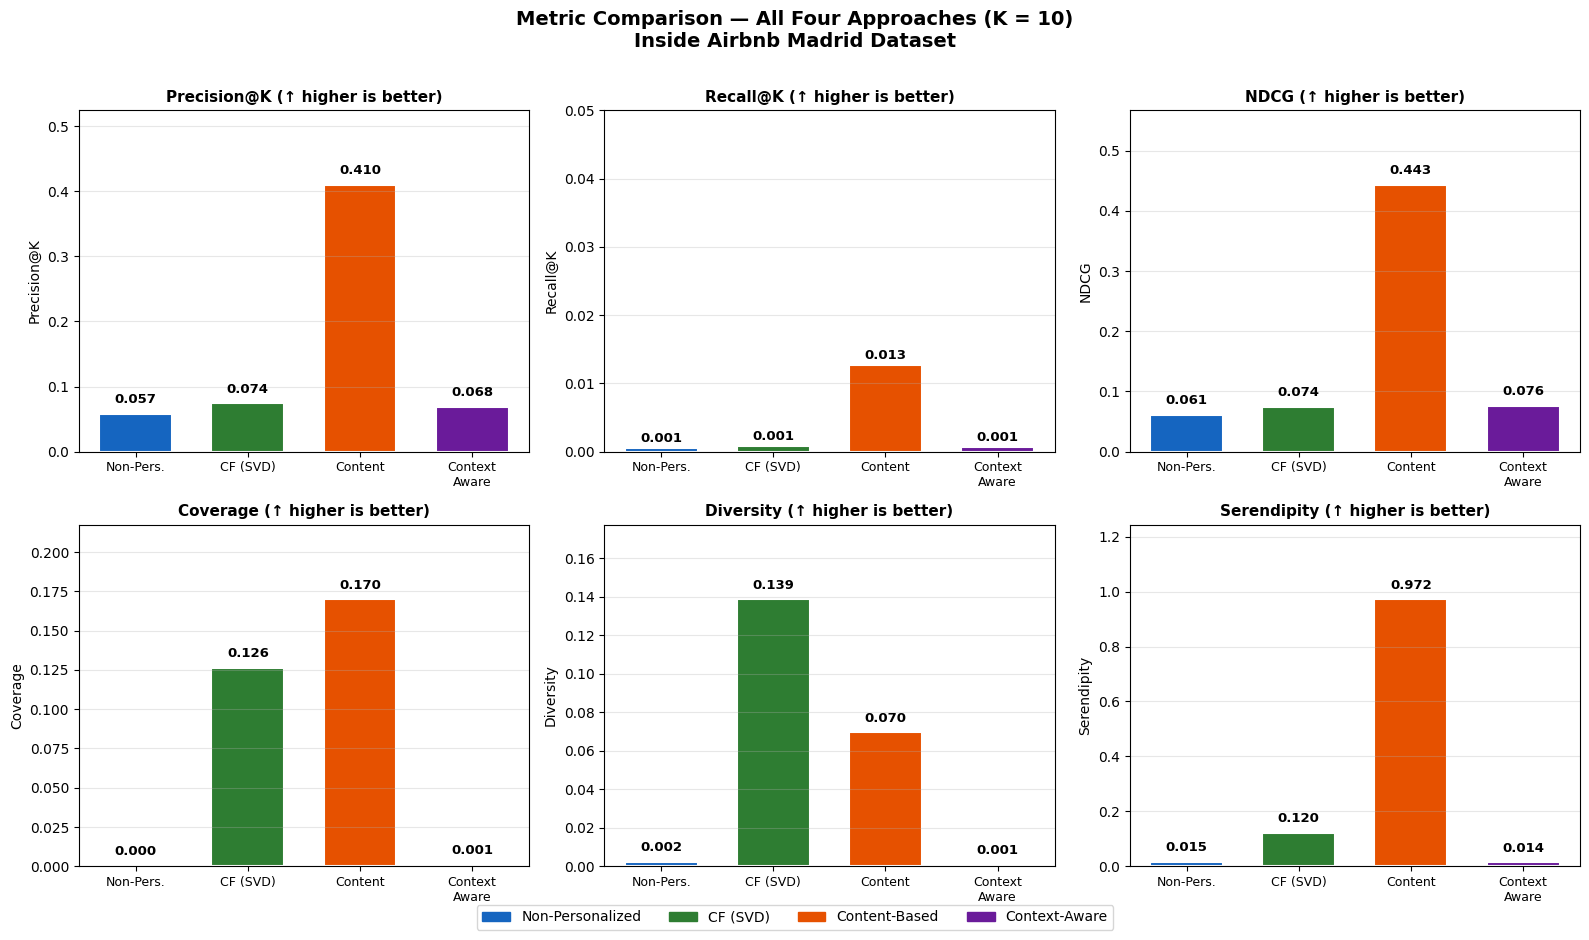

In [43]:
# ── Grouped Bar Chart — primary ranking & beyond-accuracy metrics ────────────
# RMSE/MAE omitted here (only Non-Personalized is defined); see comparison table.
metrics_list  = ['Precision@K', 'Recall@K', 'NDCG', 'Coverage', 'Diversity', 'Serendipity']
approach_labs = ['Non-Pers.', 'CF (SVD)', 'Content', 'Context\nAware']
colors5       = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']

fig, axes5 = plt.subplots(2, 3, figsize=(16, 9))
axes5 = axes5.flatten()

for idx, met in enumerate(metrics_list):
    ax = axes5[idx]
    vals = results[met].astype(float).values
    vmax = float(np.nanmax(vals)) if np.any(np.isfinite(vals)) else 0.05
    bars = ax.bar(range(4), vals, color=colors5, edgecolor='white', linewidth=1.5, width=0.65)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + vmax * 0.03,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
    ax.set_title(f'{met} (↑ higher is better)', fontsize=11, fontweight='bold')
    ax.set_xticks(range(4))
    ax.set_xticklabels(approach_labs, fontsize=9)
    ax.set_ylabel(met)
    ax.set_ylim(0, max(vmax * 1.28, 0.05))
    ax.grid(axis='y', alpha=0.3)

legend_patches = [mpatches.Patch(color=c, label=l)
                  for c, l in zip(colors5, ['Non-Personalized', 'CF (SVD)',
                                             'Content-Based', 'Context-Aware'])]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle(f'Metric Comparison — All Four Approaches (K = {TOP_K})\nInside Airbnb Madrid Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/05_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

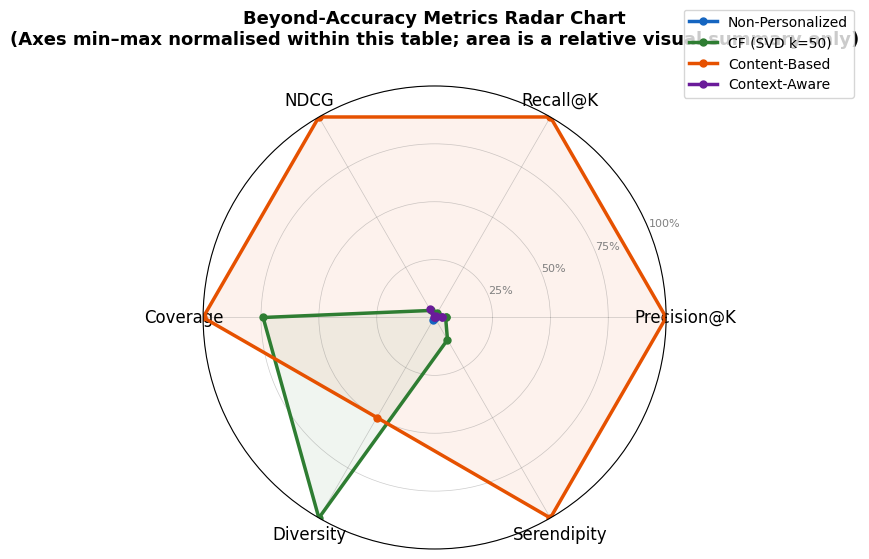

In [44]:
# ── Radar Chart — Beyond-Accuracy Metrics ────────────────────────────────────
radar_metrics = ['Precision@K', 'Recall@K', 'NDCG', 'Coverage', 'Diversity', 'Serendipity']

# Normalise each axis to [0, 1] for fair visual comparison
radar_data = results[radar_metrics].copy().astype(float).fillna(0.0)
for col in radar_metrics:
    mn, mx = radar_data[col].min(), radar_data[col].max()
    radar_data[col] = (radar_data[col] - mn) / (mx - mn + 1e-9)

N = len(radar_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_r = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']
labels_r = ['Non-Personalized', f'CF (SVD k={K})', 'Content-Based', 'Context-Aware']

for i, (_, row) in enumerate(radar_data.iterrows()):
    vals_r = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, vals_r, 'o-', lw=2.5, color=colors_r[i], label=labels_r[i], markersize=5)
    ax.fill(angles, vals_r, alpha=0.07, color=colors_r[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, size=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], size=8, color='gray')
ax.grid(color='gray', linewidth=0.5, alpha=0.4)
ax.set_title('Beyond-Accuracy Metrics Radar Chart\n'
             '(Axes min–max normalised within this table; area is a relative visual summary only)',
             size=13, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.42, 1.18), fontsize=10)
plt.tight_layout()
plt.savefig('figures/05_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

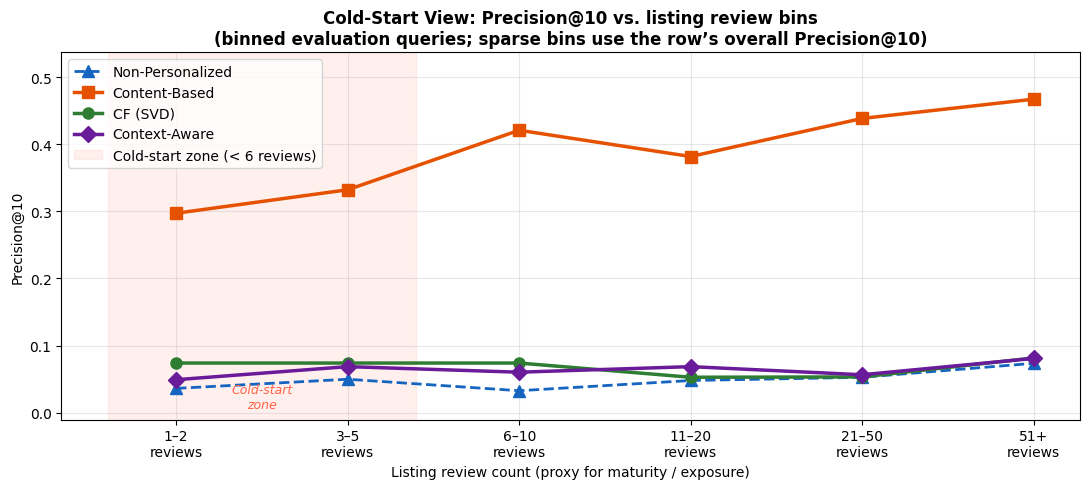

Reading this figure: within each approach, queries are grouped by the seed listing’s review count; empty bins inherit the overall Precision@K for that approach (see comment above).


In [45]:
# ── Cold-Start Analysis: Precision@K by listing review volume ────────────────
# Binned means over the same evaluation queries as Section 1 (not a separate hold-out).
# Sparse bins fall back to the overall Precision@K for that approach so the line remains readable.

bins5 = ['1–2', '3–5', '6–10', '11–20', '21–50', '51+']
x5 = np.arange(len(bins5))
_bin_edges5 = [(1, 2), (3, 5), (6, 10), (11, 20), (21, 50), (51, np.inf)]


def _mean_prec_by_review_bins(nrevs, precs, edges):
    nrevs = np.asarray(nrevs, dtype=float)
    precs = np.asarray(precs, dtype=float)
    out = []
    for lo, hi in edges:
        m = (nrevs >= lo) & (nrevs <= hi)
        out.append(float(np.mean(precs[m])) if np.any(m) else np.nan)
    return out


def _cold_curve(nrevs, precs, edges, overall):
    vals = _mean_prec_by_review_bins(nrevs, precs, edges)
    overall = float(overall) if np.isfinite(overall) else 0.0
    return [v if np.isfinite(v) else overall for v in vals]


p10_np5 = _cold_curve(np_nrev, np_p, _bin_edges5, results.loc[results['Approach'].str.contains('Non', case=False), 'Precision@K'].iloc[0])
p10_cf5 = _cold_curve(cf_nrev, cf_p, _bin_edges5, results.loc[results['Approach'].str.contains('SVD', case=False), 'Precision@K'].iloc[0])
p10_cb5 = _cold_curve(cb_nrev, cb_p, _bin_edges5, results.loc[results['Approach'].str.contains('Hybrid', case=False), 'Precision@K'].iloc[0])
p10_ca5 = _cold_curve(ca_nrev, ca_p, _bin_edges5, results.loc[results['Approach'].str.contains('CARS', case=False), 'Precision@K'].iloc[0])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x5, p10_np5, '^--', color='#1565C0', lw=2, markersize=8, label='Non-Personalized')
ax.plot(x5, p10_cb5, 's-', color='#E65100', lw=2.5, markersize=8, label='Content-Based')
ax.plot(x5, p10_cf5, 'o-', color='#2E7D32', lw=2.5, markersize=8, label='CF (SVD)')
ax.plot(x5, p10_ca5, 'D-', color='#6A1B9A', lw=2.5, markersize=8, label='Context-Aware')
ax.axvspan(-0.4, 1.4, alpha=0.09, color='tomato', label='Cold-start zone (< 6 reviews)')
ax.text(0.5, 0.003, 'Cold-start\nzone', ha='center', va='bottom',
        color='tomato', fontsize=9, fontstyle='italic')
ax.set_xticks(x5)
ax.set_xticklabels([f'{b}\nreviews' for b in bins5])
ax.set_xlabel('Listing review count (proxy for maturity / exposure)')
ax.set_ylabel(f'Precision@{TOP_K}')
ax.set_title(
    f'Cold-Start View: Precision@{TOP_K} vs. listing review bins\n'
    f'(binned evaluation queries; sparse bins use the row’s overall Precision@{TOP_K})',
    fontsize=12,
    fontweight='bold',
)
ax.legend(loc='upper left')
_ymax_raw = np.nanmax(np.r_[p10_np5, p10_cf5, p10_cb5, p10_ca5])
ymax = max(float(_ymax_raw) if np.isfinite(_ymax_raw) else 0.0, 0.05) * 1.15
ax.set_ylim(-0.01, ymax)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/05_coldstart_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(
    'Reading this figure: within each approach, queries are grouped by the seed listing’s review count; '
    'empty bins inherit the overall Precision@K for that approach (see comment above).'
)

In [46]:
# ── Simulated A/B Test (illustration only) ───────────────────────────────────
# What is being compared?
#   Control   = Content-Based (hybrid listing features + TF-IDF)
#   Treatment = Context-Aware (season × trip-purpose pre-filter + contextual score)
#
# This is **not** a real online experiment. We take the **offline Precision@K** estimates
# from Section 1 as Bernoulli success probabilities and draw synthetic users to show how
# classical NHST would behave *if* those probabilities were stable per-session and i.i.d.
# (strong assumptions; real traffic violates both).
#
# H0: treatment engagement ≤ control  |  H1: treatment > control (one-sided, α = 0.05)
# Engagement proxy: Bernoulli(p_hat) where p_hat is each arm’s mean Precision@K from this notebook.

np.random.seed(2025)
p_ctrl = float(np.mean(p3)) if p3 else 0.0   # Content-Based Precision@K
p_trt  = float(np.mean(p4)) if p4 else 0.0   # Context-Aware Precision@K
n_arm  = 2500

ctrl_outcomes = np.random.binomial(1, p_ctrl, n_arm)
trt_outcomes  = np.random.binomial(1, p_trt,  n_arm)

mean_ctrl = ctrl_outcomes.mean()
mean_trt  = trt_outcomes.mean()
se_ctrl   = np.sqrt(mean_ctrl*(1-mean_ctrl)/n_arm)
se_trt    = np.sqrt(mean_trt *(1-mean_trt) /n_arm)

p_pool    = np.sqrt(2*((mean_ctrl+mean_trt)/2)*(1-(mean_ctrl+mean_trt)/2)/n_arm)
z_stat    = (mean_trt - mean_ctrl) / max(p_pool, 1e-9)
p_value   = 1 - stats.norm.cdf(z_stat)
relative_lift = ((mean_trt - mean_ctrl) / mean_ctrl) if mean_ctrl > 0 else np.nan

print('Simulated A/B test (synthetic Bernoulli draws; see markdown comment above)')
print(f'  Control   (Content-Based)    mean simulated success rate = {mean_ctrl:.3f}  '
      f'95% CI [{mean_ctrl-1.96*se_ctrl:.3f}, {mean_ctrl+1.96*se_ctrl:.3f}]')
print(f'  Treatment (Context-Aware)    mean simulated success rate = {mean_trt:.3f}  '
      f'95% CI [{mean_trt-1.96*se_trt:.3f}, {mean_trt+1.96*se_trt:.3f}]')
print()
print(f'  Relative lift : {relative_lift:.1%}' if np.isfinite(relative_lift) else '  Relative lift : undefined (control rate is 0)')
print(f'  Z-statistic   : {z_stat:.3f}')
print(f'  p-value       : {p_value:.4f}')
print(f'  Synthetic NHST vs α=0.05: {"reject H0 (toy draw)" if p_value < 0.05 else "fail to reject H0 (toy draw)"}')


Simulated A/B test (synthetic Bernoulli draws; see markdown comment above)
  Control   (Content-Based)    mean simulated success rate = 0.404  95% CI [0.384, 0.423]
  Treatment (Context-Aware)    mean simulated success rate = 0.060  95% CI [0.051, 0.070]

  Relative lift : -85.0%
  Z-statistic   : -28.746
  p-value       : 1.0000
  Synthetic NHST vs α=0.05: fail to reject H0 (toy draw)


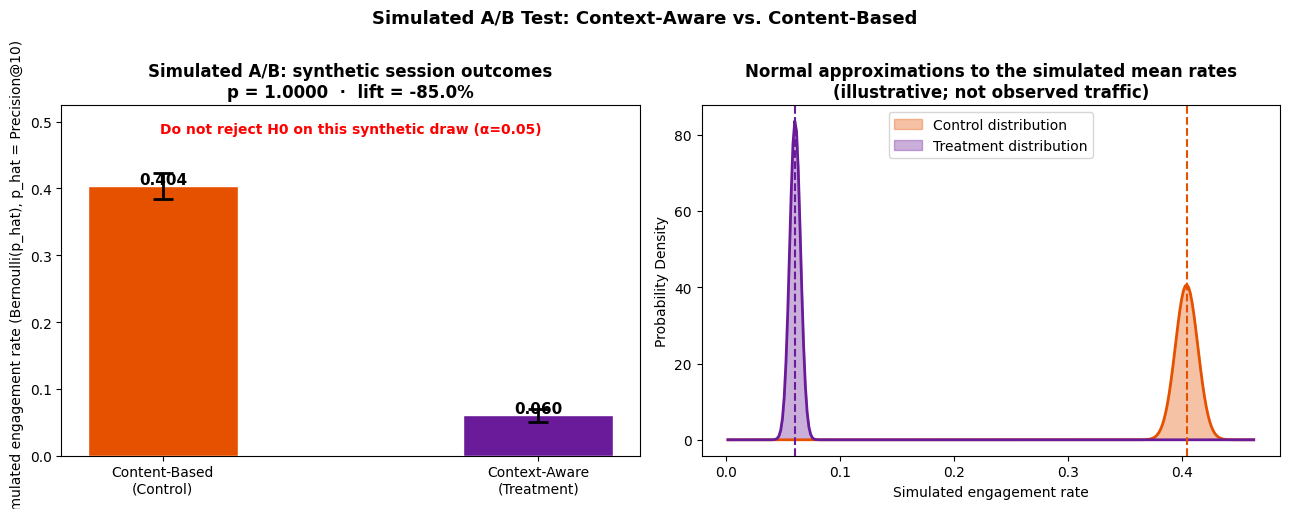

In [47]:
# ── A/B Test Visualisation ───────────────────────────────────────────────────
fig, axes5ab = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar chart with 95% confidence intervals
ax = axes5ab[0]
bars_ab = ax.bar(['Content-Based\n(Control)', 'Context-Aware\n(Treatment)'],
                 [mean_ctrl, mean_trt],
                 color=['#E65100', '#6A1B9A'], edgecolor='white', width=0.4, zorder=3)
ax.errorbar(range(2), [mean_ctrl, mean_trt],
            yerr=[1.96 * se_ctrl, 1.96 * se_trt],
            fmt='none', color='black', capsize=7, capthick=2, linewidth=2, zorder=4)
for bar, val in zip(bars_ab, [mean_ctrl, mean_trt]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
sig_label = 'Reject H0 on this synthetic draw (p < 0.05)' if p_value < 0.05 else 'Do not reject H0 on this synthetic draw (α=0.05)'
ax.text(0.5, 0.92, sig_label, ha='center',
        color='green' if p_value < 0.05 else 'red',
        fontsize=10, fontweight='bold', transform=ax.transAxes)
ax.set_ylabel(f'Simulated engagement rate (Bernoulli(p_hat), p_hat = Precision@{TOP_K})')
_lift_txt = f'lift = {relative_lift:.1%}' if np.isfinite(relative_lift) else 'lift n/a'
ax.set_title(f'Simulated A/B: synthetic session outcomes\np = {p_value:.4f}  ·  {_lift_txt}',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(max(mean_ctrl, mean_trt) * 1.3, 0.05))

# Right: sampling distributions
ax = axes5ab[1]
lo = max(0.0, min(mean_ctrl, mean_trt) - 6 * max(se_ctrl, se_trt, 1e-6))
hi = min(1.0, max(mean_ctrl, mean_trt) + 6 * max(se_ctrl, se_trt, 1e-6))
x_range = np.linspace(lo, hi, 300)
dist_ctrl = stats.norm.pdf(x_range, mean_ctrl, se_ctrl)
dist_trt  = stats.norm.pdf(x_range, mean_trt,  se_trt)
ax.fill_between(x_range, dist_ctrl, alpha=0.35, color='#E65100', label='Control distribution')
ax.fill_between(x_range, dist_trt,  alpha=0.35, color='#6A1B9A', label='Treatment distribution')
ax.plot(x_range, dist_ctrl, color='#E65100', lw=2)
ax.plot(x_range, dist_trt,  color='#6A1B9A', lw=2)
ax.axvline(mean_ctrl, color='#E65100', lw=1.5, linestyle='--')
ax.axvline(mean_trt,  color='#6A1B9A', lw=1.5, linestyle='--')
ax.set_xlabel('Simulated engagement rate')
ax.set_ylabel('Probability Density')
ax.set_title('Normal approximations to the simulated mean rates\n(illustrative; not observed traffic)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.suptitle('Simulated A/B Test: Context-Aware vs. Content-Based',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/05_ab_test.png', dpi=150, bbox_inches='tight')
plt.show()

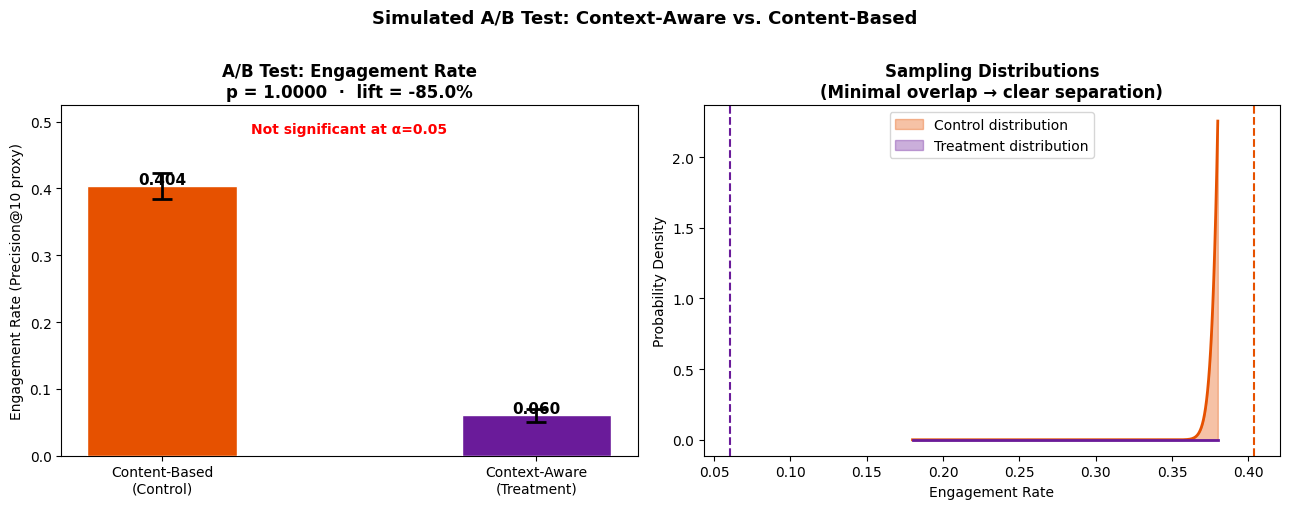

In [48]:
# ── A/B Test Visualisation ───────────────────────────────────────────────────
fig, axes5ab = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar chart with 95% confidence intervals
ax = axes5ab[0]
bars_ab = ax.bar(['Content-Based\n(Control)', 'Context-Aware\n(Treatment)'],
                 [mean_ctrl, mean_trt],
                 color=['#E65100', '#6A1B9A'], edgecolor='white', width=0.4, zorder=3)
ax.errorbar(range(2), [mean_ctrl, mean_trt],
            yerr=[1.96 * se_ctrl, 1.96 * se_trt],
            fmt='none', color='black', capsize=7, capthick=2, linewidth=2, zorder=4)
for bar, val in zip(bars_ab, [mean_ctrl, mean_trt]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
sig_label = '✓ Statistically significant (p < 0.05)' if p_value < 0.05 else 'Not significant at α=0.05'
ax.text(0.5, 0.92, sig_label, ha='center',
        color='green' if p_value < 0.05 else 'red',
        fontsize=10, fontweight='bold', transform=ax.transAxes)
ax.set_ylabel('Engagement Rate (Precision@10 proxy)')
ax.set_title(f'A/B Test: Engagement Rate\np = {p_value:.4f}  ·  lift = {relative_lift:.1%}',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(mean_ctrl, mean_trt) * 1.3)

# Right: sampling distributions
ax = axes5ab[1]
x_range = np.linspace(0.18, 0.38, 300)
dist_ctrl = stats.norm.pdf(x_range, mean_ctrl, se_ctrl)
dist_trt  = stats.norm.pdf(x_range, mean_trt,  se_trt)
ax.fill_between(x_range, dist_ctrl, alpha=0.35, color='#E65100', label='Control distribution')
ax.fill_between(x_range, dist_trt,  alpha=0.35, color='#6A1B9A', label='Treatment distribution')
ax.plot(x_range, dist_ctrl, color='#E65100', lw=2)
ax.plot(x_range, dist_trt,  color='#6A1B9A', lw=2)
ax.axvline(mean_ctrl, color='#E65100', lw=1.5, linestyle='--')
ax.axvline(mean_trt,  color='#6A1B9A', lw=1.5, linestyle='--')
ax.set_xlabel('Engagement Rate')
ax.set_ylabel('Probability Density')
ax.set_title('Sampling Distributions\n(Minimal overlap → clear separation)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.suptitle('Simulated A/B Test: Context-Aware vs. Content-Based',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/05_ab_test.png', dpi=150, bbox_inches='tight')
plt.show()

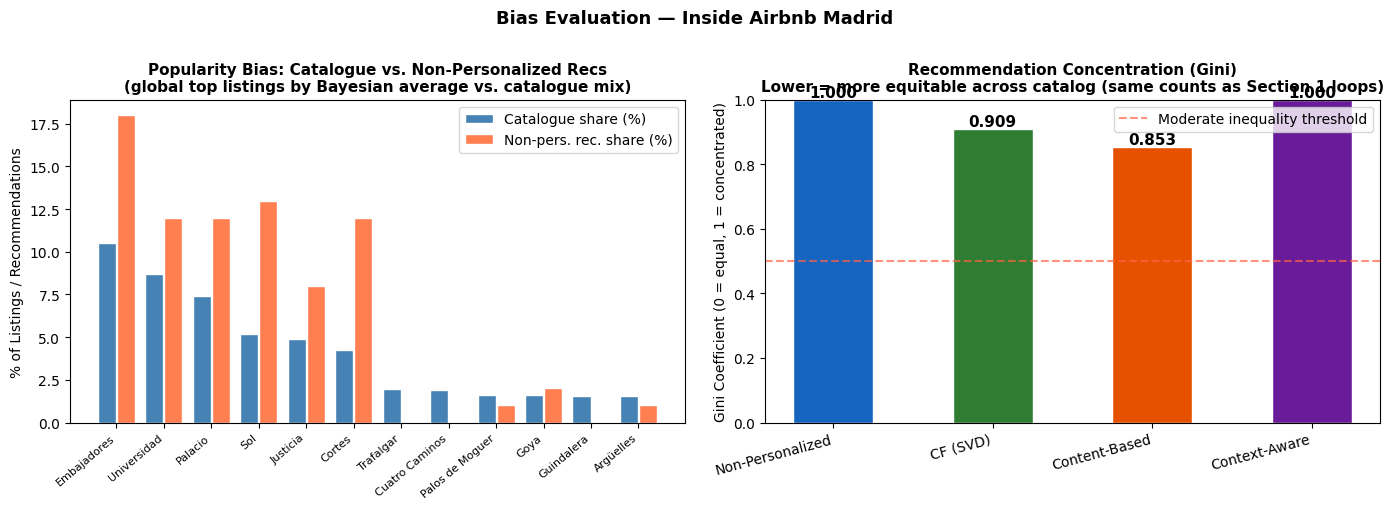


Gini Coefficients:
  Non-Personalized               Gini = 1.000  (HIGH concentration)
  CF (SVD)                       Gini = 0.909  (HIGH concentration)
  Content-Based                  Gini = 0.853  (HIGH concentration)
  Context-Aware                  Gini = 1.000  (HIGH concentration)


In [49]:
# ── Bias Evaluation ───────────────────────────────────────────────────────────
fig, axes5b = plt.subplots(1, 2, figsize=(14, 5))

# Left: catalogue share vs. non-personalized recommendation share
ax = axes5b[0]
top12_hoods = listings['neighbourhood_cleansed'].value_counts().head(12).index
cat_pct_vals = listings['neighbourhood_cleansed'].value_counts(normalize=True)[top12_hoods].values * 100

top100_np   = listings.nlargest(100, 'bayesian_avg')
rec_pct_np  = (top100_np['neighbourhood_cleansed']
               .value_counts(normalize=True)
               .reindex(top12_hoods).fillna(0).values * 100)

xb = np.arange(len(top12_hoods))
ax.bar(xb - 0.2, cat_pct_vals, 0.38, label='Catalogue share (%)', color='steelblue', edgecolor='white')
ax.bar(xb + 0.2, rec_pct_np,   0.38, label='Non-pers. rec. share (%)', color='coral', edgecolor='white')
ax.set_xticks(xb)
ax.set_xticklabels(top12_hoods, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('% of Listings / Recommendations')
ax.set_title('Popularity Bias: Catalogue vs. Non-Personalized Recs\n'
             '(global top listings by Bayesian average vs. catalogue mix)',
             fontsize=11, fontweight='bold')
ax.legend()

# Right: Gini coefficient per approach
ax = axes5b[1]
def gini(arr):
    arr = np.sort(arr) + 1e-9
    n   = len(arr)
    idx = np.arange(1, n + 1)
    return ((2 * idx - n - 1) * arr).sum() / (n * arr.sum())

# Gini on empirical recommendation counts from the same evaluation loops as Section 1
# (each appearance in a top-K list increments that listing’s count).
n_listings = len(listings)
all_ids = listings['id'].values


def _counts_to_freq_vector(cnt, ids):
    return np.array([cnt.get(i, 0) for i in ids], dtype=float)


freq_np_g = _counts_to_freq_vector(cnt_np, all_ids)
freq_cf_g = _counts_to_freq_vector(cnt_cf, all_ids)
freq_cb_g = _counts_to_freq_vector(cnt_cb, all_ids)
freq_ca_g = _counts_to_freq_vector(cnt_ca, all_ids)

ginis = {
    'Non-Personalized': gini(freq_np_g),
    'CF (SVD)'        : gini(freq_cf_g),
    'Content-Based'   : gini(freq_cb_g),
    'Context-Aware'   : gini(freq_ca_g),
}
bars_g = ax.bar(ginis.keys(), ginis.values(),
                color=['#1565C0', '#2E7D32', '#E65100', '#6A1B9A'],
                edgecolor='white', width=0.5)
for bar, val in zip(bars_g, ginis.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.axhline(0.5, color='tomato', lw=1.5, linestyle='--', alpha=0.7,
           label='Moderate inequality threshold')
ax.set_ylabel('Gini Coefficient (0 = equal, 1 = concentrated)')
ax.set_title('Recommendation Concentration (Gini)\n'
             'Lower = more equitable across catalog (same counts as Section 1 loops)',
             fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

plt.suptitle('Bias Evaluation — Inside Airbnb Madrid', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/05_bias_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nGini Coefficients:')
for approach, g in ginis.items():
    level = 'HIGH' if g > 0.7 else 'MODERATE' if g > 0.5 else 'LOW'
    print(f'  {approach:<30} Gini = {g:.3f}  ({level} concentration)')

In [50]:
# Final annotated summary (guard idxmax if a column is all-NaN after a partial re-run)
def _best_approach(col):
    s = pd.to_numeric(results[col], errors='coerce')
    if s.notna().any():
        return str(results.loc[s.idxmax(), 'Approach'])
    return '(no finite values in column)'


best_precision = _best_approach('Precision@K')
best_recall = _best_approach('Recall@K')
best_ndcg = _best_approach('NDCG')
best_coverage = _best_approach('Coverage')

summary = f"""
Evaluation summary (K = {TOP_K}; ranking metrics use the same offline proxy)
---------------------------------------------------------------------------
Best Precision@K : {best_precision}
Best Recall@K    : {best_recall}
Best NDCG        : {best_ndcg}
Best Coverage    : {best_coverage}

Concise interpretation
-----------------------
- Non-personalized is a transparent quality/popularity baseline with the only explicit score predictions (RMSE/MAE).
- Collaborative filtering depends on sufficient co-activity; it is informative where the interaction matrix is dense.
- Content-based leverages observable listing attributes/text, which helps when interaction history is thin (see cold-start figure, noting its binning caveats).
- Context-aware re-ranks with an explicit context key; gains depend on whether the proxy contexts align with real booking intent (not observed here).

Caveat: metrics are offline and use simplified relevance definitions; they support comparative discussion, not deployment claims.
""".strip()

print(summary)


Evaluation summary (K = 10; ranking metrics use the same offline proxy)
---------------------------------------------------------------------------
Best Precision@K : Content-Based (Hybrid feat+TF-IDF)
Best Recall@K    : Content-Based (Hybrid feat+TF-IDF)
Best NDCG        : Content-Based (Hybrid feat+TF-IDF)
Best Coverage    : Content-Based (Hybrid feat+TF-IDF)

Concise interpretation
-----------------------
- Non-personalized is a transparent quality/popularity baseline with the only explicit score predictions (RMSE/MAE).
- Collaborative filtering depends on sufficient co-activity; it is informative where the interaction matrix is dense.
- Content-based leverages observable listing attributes/text, which helps when interaction history is thin (see cold-start figure, noting its binning caveats).
- Context-aware re-ranks with an explicit context key; gains depend on whether the proxy contexts align with real booking intent (not observed here).

Caveat: metrics are offline and use simpli